In [2]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.nn import Embedding, LSTM, Linear
from torch.utils.data.sampler import WeightedRandomSampler
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

from random import shuffle

import re
import pymorphy2
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from gensim.models import Phrases

import time

import json

from tqdm import tqdm

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [ ]:
train = pd.read_csv('datasets/train.csv', index_col=0)
train = train.dropna()
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45398 entries, 12405 to 13043
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   45398 non-null  object
 1   text    45398 non-null  object
 2   from    45398 non-null  object
 3   lemma   45398 non-null  object
dtypes: object(4)
memory usage: 1.7+ MB


In [ ]:
test = pd.read_csv('datasets/test.csv', index_col=0)
test = test.dropna()
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5960 entries, 14745 to 20671
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5960 non-null   object
 1   text    5960 non-null   object
 2   from    5960 non-null   object
 3   lemma   5960 non-null   object
dtypes: object(4)
memory usage: 232.8+ KB


In [7]:
score_enc = OneHotEncoder(handle_unknown='ignore')
X = test.label.to_numpy().reshape(-1, 1)

unique_items = np.unique(X).reshape(-1, 1)
score_enc.fit(unique_items)

print('Категории:', score_enc.categories_, sep='\n')
print()
for i, desc in zip(score_enc.categories_[0], ['Отрицательные\t', 'Положительные\t']):
    print(desc, i, score_enc.transform(np.array([i]).reshape(-1, 1)).toarray())

Категории:
[array(['negative', 'positive'], dtype=object)]

Отрицательные	 negative [[1. 0.]]
Положительные	 positive [[0. 1.]]


In [8]:
def convert_label(df):
    return score_enc.transform(df.to_numpy().reshape(-1, 1))

In [9]:
X_train = train.lemma.tolist()
y_train = convert_label(train.label)
len(X_train), y_train

(45398,
 <45398x2 sparse matrix of type '<class 'numpy.float64'>'
 	with 45398 stored elements in Compressed Sparse Row format>)

In [45]:
# y_train = convert_label(train.label)

In [10]:
X_train = X_train[:-8]
y_train = y_train[:-8]
y_train, len(X_train)

(<45390x2 sparse matrix of type '<class 'numpy.float64'>'
 	with 45390 stored elements in Compressed Sparse Row format>,
 45390)

In [11]:
X_test = test.lemma.tolist()
y_test = convert_label(test.label)
len(X_test), y_test

(5960,
 <5960x2 sparse matrix of type '<class 'numpy.float64'>'
 	with 5960 stored elements in Compressed Sparse Row format>)

In [12]:
stop_list = stopwords.words("russian")
stop_list.extend(['это', 'который', 'всё', 'весь', 'свой', 'наш', 'ещё', 'также', 'ха_хий', 'ха', 'х', 'x', 'п', 'ахи', ''])

for i in ['не', 'нет', 'вдруг', 'ни', 'опять', 'ничего', 'без', 'тоже', 'совсем', 'хорошо', 'лучше']:
    stop_list.remove(i)

In [13]:
def del_stopwords(texts):
    idx = 0
    result = []

    while idx < len(texts):
        tmp = texts[idx].split(' ')
        result.append([])
        for i in tmp:
            if i not in stop_list:
                result[idx].append(i)
                
        idx+=1
    return result

In [14]:
padding = '__pad__'

In [15]:
all_words = ' '.join(X_train)
unique_words = set(all_words.split(' ') + [padding]) - set(stop_list)
word_dict = {value: key for key, value in enumerate(unique_words)}
len(word_dict), word_dict[padding]

(65874, 56775)

In [15]:
word_dict

{'пистолет': 0,
 'смоки': 1,
 'переплетный': 2,
 'трехместный': 3,
 'этакий': 4,
 'вымещать': 5,
 'разумеется': 6,
 'попастьтеперить': 7,
 'ресурснея': 8,
 'сердобольный': 9,
 'заглавный': 10,
 'вонь': 11,
 'ребятушки': 12,
 'хуяс': 13,
 'маю': 14,
 'появиться': 15,
 'обрести': 16,
 'корпаративный': 17,
 'жадный': 18,
 'сочетаться': 19,
 'смывать': 20,
 'карбышев': 21,
 'различимый': 22,
 'неинтересоваться': 23,
 'чрезмерно': 24,
 'специфический': 25,
 'типя': 26,
 'недолгий': 27,
 'задушить': 28,
 'шем': 29,
 'надрываться': 30,
 'разорись': 31,
 'газонокосилка': 32,
 'сердечко': 33,
 'прослойка': 34,
 'необновлять': 35,
 'кверху': 36,
 'неубранные': 37,
 'бакалаврит': 38,
 'огромнейшее': 39,
 'алишев': 40,
 'генетический': 41,
 'преподаватель': 42,
 'впустую': 43,
 'ежеквартальный': 44,
 'вникать': 45,
 'облицовка': 46,
 'прикрепляла': 47,
 'поточный': 48,
 'сломать': 49,
 'доносить': 50,
 'таскаться': 51,
 'шлейф': 52,
 'спичей': 53,
 'адвокатура': 54,
 'приемник': 55,
 'биотехнологи

In [16]:
def text2numbers(text, dict_): 
    text = text.split(' ')
    sequence = []

    for i in text:
        if i in dict_.keys():
            sequence.append(dict_[i])

    return sequence

In [17]:
def texts2tokens(row):
    return [text2numbers(i, dict_=word_dict) for i in row]

In [18]:
def set_text_len(texts, max_len, pad=0):
    array = np.zeros([len(texts), max_len])

    i = 0
    for value in texts:
        tmp = max_len-len(value)
        tmp = tmp if tmp > 0 else 0

        # text = np.concatenate((value[:max_len], np.zeros(tmp)))
        # print(np.full(tmp, pad))
        text = np.concatenate((value[:max_len], np.full(tmp, pad)))
        array[i] = text
        i+=1

    return array 

In [71]:
np.full((10, 2), 12)

array([[12, 12],
       [12, 12],
       [12, 12],
       [12, 12],
       [12, 12],
       [12, 12],
       [12, 12],
       [12, 12],
       [12, 12],
       [12, 12]])

In [78]:
x = texts2tokens(test.lemma.tolist()[:5])

x = set_text_len(x, max_len, pad = word_dict[padding])
x

array([[42104., 45947., 45947., ..., 45947., 45947., 45947.],
       [17071., 61758., 45947., ..., 45947., 45947., 45947.],
       [56053., 45552., 45947., ..., 45947., 45947., 45947.],
       [10237., 63232., 45947., ..., 45947., 45947., 45947.],
       [50329.,  6502., 17524., ..., 45947., 45947., 45947.]])

In [19]:
X_train = texts2tokens(X_train)
X_test = texts2tokens(X_test)

In [20]:
max_len = 230
X_train = set_text_len(X_train, max_len, pad = word_dict[padding])
X_test = set_text_len(X_test, max_len, pad = word_dict[padding])

X_train.shape, X_test.shape

((45390, 230), (5960, 230))

In [21]:
train_pre = [np.argmax(i) for i in y_train]

unique, counts = np.unique(train_pre, return_counts=True)
print(unique, counts)
counts = [i/len(train_pre) for i in counts]
class_weights = np.array(counts)
print(class_weights)

[0 1] [14593 30797]
[0.32150253 0.67849747]


# Model 1

In [130]:
batch_size = 10

train_ds = TensorDataset(torch.IntTensor(X_train), torch.FloatTensor(y_train.toarray()))
test_ds = TensorDataset(torch.IntTensor(X_test), torch.FloatTensor(y_test.toarray()))

train_loader = DataLoader(train_ds,  batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=True)

In [131]:
class GRU(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_size, output_size, padding_idx):
        super(GRU, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        self.embedding = Embedding(input_size, embedding_dim, padding_idx = padding_idx)
        self.gru = nn.GRU(embedding_dim, hidden_size, num_layers=2, batch_first=True) #  dropout=0.25
        self.fc = Linear(hidden_size, output_size)
        self.sig = nn.Sigmoid()

    def forward(self, text):
        embedded = self.embedding(text)
        # print(embedded.shape)
        output, hidden = self.gru(embedded)
        # print(output.shape)

        output = self.fc(output[:, -1, :])
        output = self.sig(output)
       
        return output

In [28]:
model = GRU(input_size=len(word_dict),
            embedding_dim=256,
            hidden_size=512,
            output_size=2,
            padding_idx = word_dict[padding]
)

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
weight = torch.Tensor(class_weights).to(device)
print('Weight', weight)
loss_fn = nn.BCELoss(weight=weight)

print(model)

Weight tensor([0.3215, 0.6785], device='cuda:0')
GRU(
  (embedding): Embedding(65874, 256, padding_idx=45947)
  (gru): GRU(256, 512, num_layers=2, batch_first=True)
  (fc): Linear(in_features=512, out_features=2, bias=True)
  (sig): Sigmoid()
)


In [22]:
metrics_dict_train = {}
metrics_dict_test = {}

In [23]:
def metrics_(model, data_loader, device, epoch, is_train=False):
    correct = 0

    pred = []
    target = []
    total_loss = 0
    
    with torch.no_grad():
        for i, (X, y) in enumerate(data_loader):
            X = X.to(device)
            y = y.to(device)
            outputs = model(X)
            total_loss += loss_fn(outputs, y)

            pred.extend(outputs.cpu())
            target.extend(y.cpu())


        pred_bin = [i.argmax() for i in pred]
        label_bin = [i.argmax() for i in target]
        
        f1_score = metrics.f1_score(pred_bin, label_bin, average='weighted') #.accuracy_score(predicted, label)
        precision = metrics.precision_score(pred_bin, label_bin, average='weighted')
        recall = metrics.recall_score(pred_bin, label_bin, average='weighted')
        accuracy = metrics.accuracy_score(pred_bin, label_bin)

        tmp_metrics = {'f1-score': f1_score, 'precision': precision, 'recall': recall, 'accuracy': accuracy}
        if is_train:
            metrics_dict_train[epoch] = tmp_metrics
        else:
            metrics_dict_test[epoch] = tmp_metrics

        print('F1-мера:',str('{:04.2f}'.format(f1_score*100))+'%')
        print('Precision:',str('{:04.2f}'.format(precision*100))+'%')
        print('Recall:',str('{:04.2f}'.format(recall*100))+'%')
        print('Accuracy:',str('{:04.2f}'.format(accuracy*100))+'%')
        print('Loss:',str('{:04.2f}'.format(total_loss)))

        print('Матрица ошибок:')
        print(pd.DataFrame(confusion_matrix(label_bin, pred_bin)))
        print('------------------------------------------------')
        print('Отчет о классификации:')
        print(classification_report(label_bin, pred_bin))

In [24]:
def train_model(model, epochs = 10, prefix='e'):
    start = time.time()
    global metrics_dict_train, metrics_dict_test
    metrics_dict_train = {}
    metrics_dict_test = {}
    
    for epoch in range(epochs):
        model.train()
        for i, data in enumerate(tqdm(train_loader)):
            text, labels = data
            text = text.to(device)
            labels = labels.to(device)
        
            optimizer.zero_grad()
            outputs = model(text)
            # print(outputs.shape, labels.shape)
            loss = loss_fn(outputs, labels) # .reshape(-1, 2)
            loss.backward()
            optimizer.step()

        # torch.save(model, f'models/{prefix}{epoch}_lstm.pt')
    
        with torch.set_grad_enabled(False):
            print(f'Epoch: {epoch}')
            print('Train')
            metrics_(model, train_loader, device, epoch, is_train=True)
            print('Test')
            metrics_(model, test_loader, device, epoch)

        
    print(f'Total time: {(time.time() - start)/60:.2f} min')

In [25]:
def draw_metrics():
    fig, ax = plt.subplots(2, 2)
    fig.suptitle('Метрики')
    fig.set_size_inches(15, 7)
    
    amount = len(metrics_dict_train)
    
    for i, name in enumerate(['accuracy', 'precision', 'recall', 'f1-score']):
        train_metrics = [metrics_dict_train[i][name] for i in range(amount)]
        test_metrics = [metrics_dict_test[i][name] for i in range(amount)]
    
        x = list(range(amount))
        current_ax = ax[i%2][i//2]
        current_ax.plot(x, train_metrics, label='Train')
        current_ax.plot(x, test_metrics, label='Test')
        current_ax.set_title(name)
        current_ax.legend(loc='upper left')
        current_ax.grid()

In [29]:
train_model(model, epochs = 10)

100%|███████████████████████████████████████| 4539/4539 [03:36<00:00, 20.95it/s]


Epoch: 0
Train
F1-мера: 87.55%
Precision: 87.53%
Recall: 87.56%
Accuracy: 87.56%
Loss: 647.26
Матрица ошибок:
       0      1
0  11836   2757
1   2889  27908
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.80      0.81      0.81     14593
           1       0.91      0.91      0.91     30797

    accuracy                           0.88     45390
   macro avg       0.86      0.86      0.86     45390
weighted avg       0.88      0.88      0.88     45390

Test
F1-мера: 76.23%
Precision: 76.88%
Recall: 76.14%
Accuracy: 76.14%
Loss: 141.59
Матрица ошибок:
      0     1
0  2087   892
1   530  2451
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.80      0.70      0.75      2979
           1       0.73      0.82      0.78      2981

    accuracy                           0.76      5960
   macro av

100%|███████████████████████████████████████| 4539/4539 [03:36<00:00, 20.96it/s]


Epoch: 1
Train
F1-мера: 91.71%
Precision: 92.46%
Recall: 91.50%
Accuracy: 91.50%
Loss: 443.91
Матрица ошибок:
       0      1
0  11497   3096
1    764  30033
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     14593
           1       0.91      0.98      0.94     30797

    accuracy                           0.91     45390
   macro avg       0.92      0.88      0.90     45390
weighted avg       0.92      0.91      0.91     45390

Test
F1-мера: 75.57%
Precision: 79.89%
Recall: 74.93%
Accuracy: 74.93%
Loss: 159.76
Матрица ошибок:
      0     1
0  1763  1216
1   278  2703
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.86      0.59      0.70      2979
           1       0.69      0.91      0.78      2981

    accuracy                           0.75      5960
   macro av

100%|███████████████████████████████████████| 4539/4539 [03:36<00:00, 20.93it/s]


...

Epoch: 7
Train
F1-мера: 93.85%
Precision: 93.99%
Recall: 93.80%
Accuracy: 93.80%
Loss: 361.11
Матрица ошибок:
       0      1
0  12739   1854
1    961  29836
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     14593
           1       0.94      0.97      0.95     30797

    accuracy                           0.94     45390
   macro avg       0.94      0.92      0.93     45390
weighted avg       0.94      0.94      0.94     45390

Test
F1-мера: 75.52%
Precision: 76.97%
Recall: 75.32%
Accuracy: 75.32%
Loss: 187.41
Матрица ошибок:
      0     1
0  1973  1006
1   465  2516
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.81      0.66      0.73      2979
           1       0.71      0.84      0.77      2981

    accuracy                           0.75      5960
   macro av

100%|███████████████████████████████████████| 4539/4539 [03:38<00:00, 20.81it/s]


Epoch: 8
Train
F1-мера: 95.07%
Precision: 95.07%
Recall: 95.07%
Accuracy: 95.07%
Loss: 299.03
Матрица ошибок:
       0      1
0  13472   1121
1   1116  29681
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     14593
           1       0.96      0.96      0.96     30797

    accuracy                           0.95     45390
   macro avg       0.94      0.94      0.94     45390
weighted avg       0.95      0.95      0.95     45390

Test
F1-мера: 75.92%
Precision: 76.71%
Recall: 75.81%
Accuracy: 75.81%
Loss: 188.68
Матрица ошибок:
      0     1
0  2058   921
1   521  2460
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.80      0.69      0.74      2979
           1       0.73      0.83      0.77      2981

    accuracy                           0.76      5960
   macro av

100%|███████████████████████████████████████| 4539/4539 [03:35<00:00, 21.06it/s]


Epoch: 9
Train
F1-мера: 93.98%
Precision: 94.54%
Recall: 93.85%
Accuracy: 93.85%
Loss: 353.01
Матрица ошибок:
       0      1
0  12172   2421
1    372  30425
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90     14593
           1       0.93      0.99      0.96     30797

    accuracy                           0.94     45390
   macro avg       0.95      0.91      0.93     45390
weighted avg       0.94      0.94      0.94     45390

Test
F1-мера: 73.50%
Precision: 77.69%
Recall: 72.82%
Accuracy: 72.82%
Loss: 232.82
Матрица ошибок:
      0     1
0  1704  1275
1   345  2636
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.83      0.57      0.68      2979
           1       0.67      0.88      0.76      2981

    accuracy                           0.73      5960
   macro av

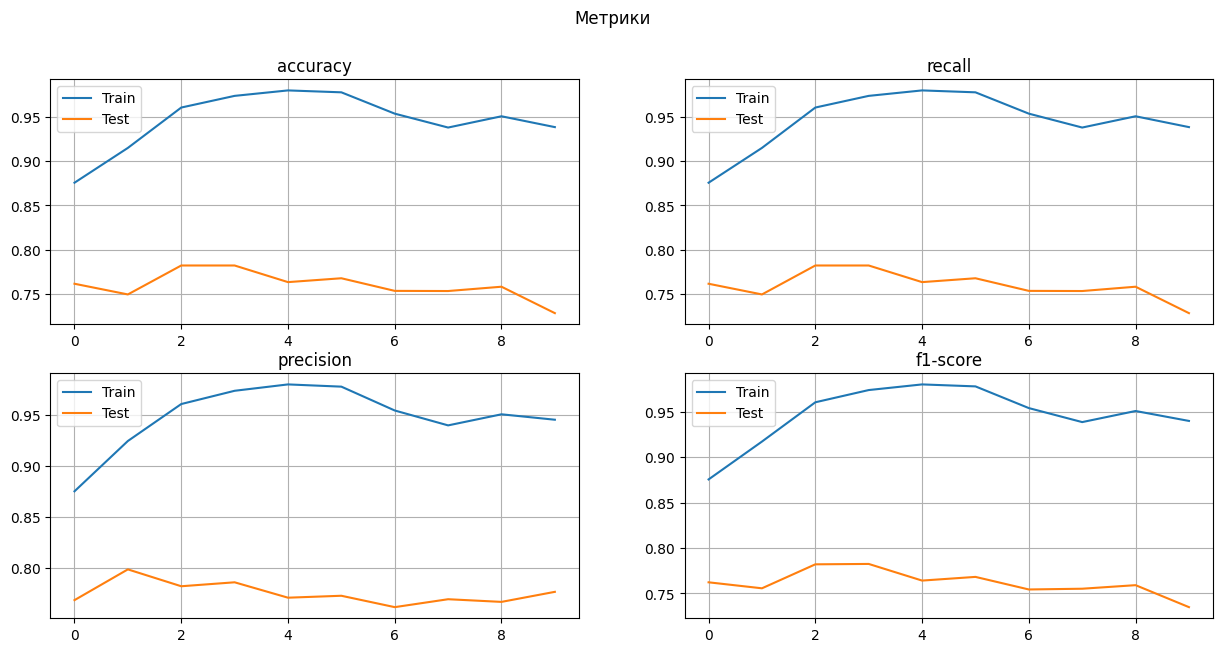

In [30]:
draw_metrics()

# Model 1.2

In [31]:
model = GRU(input_size=len(word_dict),
            embedding_dim=64,
            hidden_size=128,
            output_size=2,
            padding_idx = word_dict[padding]
)

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
weight = torch.Tensor(class_weights).to(device)
print('Weight', weight)
loss_fn = nn.BCELoss(weight=weight)

print(model)

Weight tensor([0.3215, 0.6785], device='cuda:0')
GRU(
  (embedding): Embedding(65874, 64, padding_idx=45947)
  (gru): GRU(64, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (sig): Sigmoid()
)


In [32]:
train_model(model, epochs = 10)

100%|██████████████████████████████████████| 4539/4539 [00:23<00:00, 196.60it/s]


Epoch: 0
Train
F1-мера: 85.58%
Precision: 85.94%
Recall: 85.38%
Accuracy: 85.38%
Loss: 717.09
Матрица ошибок:
       0      1
0  10600   3993
1   2644  28153
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.80      0.73      0.76     14593
           1       0.88      0.91      0.89     30797

    accuracy                           0.85     45390
   macro avg       0.84      0.82      0.83     45390
weighted avg       0.85      0.85      0.85     45390

Test
F1-мера: 75.01%
Precision: 77.04%
Recall: 74.71%
Accuracy: 74.71%
Loss: 143.73
Матрица ошибок:
      0     1
0  1904  1075
1   432  2549
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.82      0.64      0.72      2979
           1       0.70      0.86      0.77      2981

    accuracy                           0.75      5960
   macro av

100%|██████████████████████████████████████| 4539/4539 [00:23<00:00, 196.46it/s]


Epoch: 1
Train
F1-мера: 89.98%
Precision: 90.05%
Recall: 90.09%
Accuracy: 90.09%
Loss: 531.96
Матрица ошибок:
       0      1
0  13003   1590
1   2909  27888
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85     14593
           1       0.95      0.91      0.93     30797

    accuracy                           0.90     45390
   macro avg       0.88      0.90      0.89     45390
weighted avg       0.90      0.90      0.90     45390

Test
F1-мера: 78.56%
Precision: 78.57%
Recall: 78.56%
Accuracy: 78.56%
Loss: 133.71
Матрица ошибок:
      0     1
0  2317   662
1   616  2365
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78      2979
           1       0.78      0.79      0.79      2981

    accuracy                           0.79      5960
   macro av

100%|██████████████████████████████████████| 4539/4539 [00:23<00:00, 196.47it/s]


...

Epoch: 7
Train
F1-мера: 99.21%
Precision: 99.21%
Recall: 99.21%
Accuracy: 99.21%
Loss: 51.71
Матрица ошибок:
       0      1
0  14392    201
1    159  30638
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     14593
           1       0.99      0.99      0.99     30797

    accuracy                           0.99     45390
   macro avg       0.99      0.99      0.99     45390
weighted avg       0.99      0.99      0.99     45390

Test
F1-мера: 76.73%
Precision: 77.48%
Recall: 76.63%
Accuracy: 76.63%
Loss: 291.37
Матрица ошибок:
      0     1
0  2088   891
1   502  2479
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.81      0.70      0.75      2979
           1       0.74      0.83      0.78      2981

    accuracy                           0.77      5960
   macro avg

100%|██████████████████████████████████████| 4539/4539 [00:23<00:00, 192.95it/s]


Epoch: 8
Train
F1-мера: 99.21%
Precision: 99.21%
Recall: 99.21%
Accuracy: 99.21%
Loss: 49.83
Матрица ошибок:
       0      1
0  14430    163
1    197  30600
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     14593
           1       0.99      0.99      0.99     30797

    accuracy                           0.99     45390
   macro avg       0.99      0.99      0.99     45390
weighted avg       0.99      0.99      0.99     45390

Test
F1-мера: 77.78%
Precision: 78.10%
Recall: 77.73%
Accuracy: 77.73%
Loss: 285.09
Матрица ошибок:
      0     1
0  2189   790
1   537  2444
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.80      0.73      0.77      2979
           1       0.76      0.82      0.79      2981

    accuracy                           0.78      5960
   macro avg

100%|██████████████████████████████████████| 4539/4539 [00:23<00:00, 195.79it/s]


Epoch: 9
Train
F1-мера: 99.19%
Precision: 99.20%
Recall: 99.18%
Accuracy: 99.18%
Loss: 48.25
Матрица ошибок:
       0      1
0  14247    346
1     24  30773
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     14593
           1       0.99      1.00      0.99     30797

    accuracy                           0.99     45390
   macro avg       0.99      0.99      0.99     45390
weighted avg       0.99      0.99      0.99     45390

Test
F1-мера: 75.70%
Precision: 77.88%
Recall: 75.39%
Accuracy: 75.39%
Loss: 362.07
Матрица ошибок:
      0     1
0  1913  1066
1   401  2580
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.83      0.64      0.72      2979
           1       0.71      0.87      0.78      2981

    accuracy                           0.75      5960
   macro avg

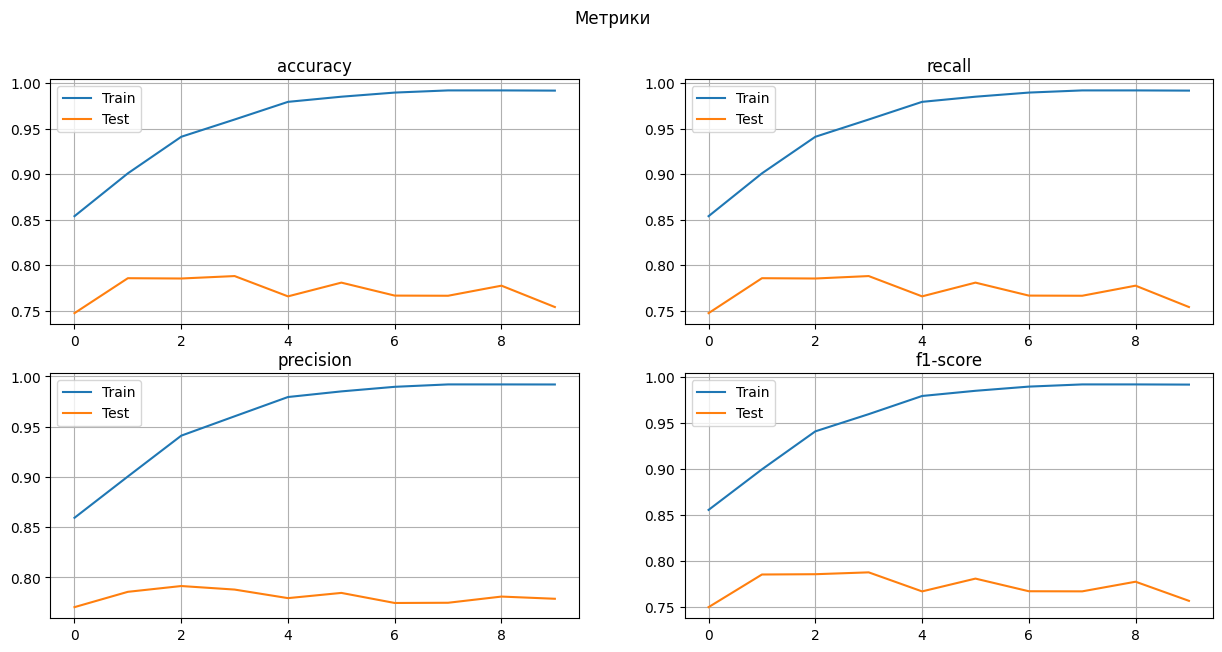

In [33]:
draw_metrics()

# Model 1.3
correct pad_idx in Embedding layer

In [132]:
model = GRU(input_size=len(word_dict),
            embedding_dim=64,
            hidden_size=128,
            output_size=2,
            padding_idx = word_dict[padding]
)

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
weight = torch.Tensor(class_weights).to(device)
print('Weight', weight)
loss_fn = nn.BCELoss(weight=weight)

print(model)

Weight tensor([0.3215, 0.6785], device='cuda:0')
GRU(
  (embedding): Embedding(65874, 64, padding_idx=45947)
  (gru): GRU(64, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (sig): Sigmoid()
)


In [133]:
train_model(model, epochs = 10)

100%|██████████████████████████████████████| 4539/4539 [00:22<00:00, 200.52it/s]


Epoch: 0
Train
F1-мера: 80.57%
Precision: 80.80%
Recall: 80.41%
Accuracy: 80.41%
Loss: 910.90
Матрица ошибок:
      0      1
0  9713   4880
1  4012  26785
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.71      0.67      0.69     14593
           1       0.85      0.87      0.86     30797

    accuracy                           0.80     45390
   macro avg       0.78      0.77      0.77     45390
weighted avg       0.80      0.80      0.80     45390

Test
F1-мера: 71.19%
Precision: 72.72%
Recall: 70.92%
Accuracy: 70.92%
Loss: 162.61
Матрица ошибок:
      0     1
0  1830  1149
1   584  2397
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.76      0.61      0.68      2979
           1       0.68      0.80      0.73      2981

    accuracy                           0.71      5960
   macro avg  

100%|██████████████████████████████████████| 4539/4539 [00:22<00:00, 202.67it/s]


Epoch: 1
Train
F1-мера: 87.67%
Precision: 88.48%
Recall: 87.35%
Accuracy: 87.35%
Loss: 637.01
Матрица ошибок:
       0      1
0  10565   4028
1   1713  29084
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.86      0.72      0.79     14593
           1       0.88      0.94      0.91     30797

    accuracy                           0.87     45390
   macro avg       0.87      0.83      0.85     45390
weighted avg       0.87      0.87      0.87     45390

Test
F1-мера: 76.14%
Precision: 79.53%
Recall: 75.65%
Accuracy: 75.65%
Loss: 146.89
Матрица ошибок:
      0     1
0  1839  1140
1   311  2670
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.86      0.62      0.72      2979
           1       0.70      0.90      0.79      2981

    accuracy                           0.76      5960
   macro av

100%|██████████████████████████████████████| 4539/4539 [00:22<00:00, 204.29it/s]


...

Epoch: 7
Train
F1-мера: 99.09%
Precision: 99.09%
Recall: 99.09%
Accuracy: 99.09%
Loss: 63.36
Матрица ошибок:
       0      1
0  14384    209
1    205  30592
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     14593
           1       0.99      0.99      0.99     30797

    accuracy                           0.99     45390
   macro avg       0.99      0.99      0.99     45390
weighted avg       0.99      0.99      0.99     45390

Test
F1-мера: 77.16%
Precision: 77.74%
Recall: 77.08%
Accuracy: 77.08%
Loss: 265.31
Матрица ошибок:
      0     1
0  2125   854
1   512  2469
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.81      0.71      0.76      2979
           1       0.74      0.83      0.78      2981

    accuracy                           0.77      5960
   macro avg

100%|██████████████████████████████████████| 4539/4539 [00:22<00:00, 204.03it/s]


Epoch: 8
Train
F1-мера: 99.18%
Precision: 99.18%
Recall: 99.18%
Accuracy: 99.18%
Loss: 59.27
Матрица ошибок:
       0      1
0  14467    126
1    248  30549
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     14593
           1       1.00      0.99      0.99     30797

    accuracy                           0.99     45390
   macro avg       0.99      0.99      0.99     45390
weighted avg       0.99      0.99      0.99     45390

Test
F1-мера: 77.12%
Precision: 77.42%
Recall: 77.08%
Accuracy: 77.08%
Loss: 276.10
Матрица ошибок:
      0     1
0  2174   805
1   561  2420
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76      2979
           1       0.75      0.81      0.78      2981

    accuracy                           0.77      5960
   macro avg

100%|██████████████████████████████████████| 4539/4539 [00:22<00:00, 204.02it/s]


Epoch: 9
Train
F1-мера: 99.16%
Precision: 99.16%
Recall: 99.16%
Accuracy: 99.16%
Loss: 56.78
Матрица ошибок:
       0      1
0  14309    284
1     99  30698
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     14593
           1       0.99      1.00      0.99     30797

    accuracy                           0.99     45390
   macro avg       0.99      0.99      0.99     45390
weighted avg       0.99      0.99      0.99     45390

Test
F1-мера: 76.09%
Precision: 77.51%
Recall: 75.89%
Accuracy: 75.89%
Loss: 320.65
Матрица ошибок:
      0     1
0  1992   987
1   450  2531
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.82      0.67      0.73      2979
           1       0.72      0.85      0.78      2981

    accuracy                           0.76      5960
   macro avg

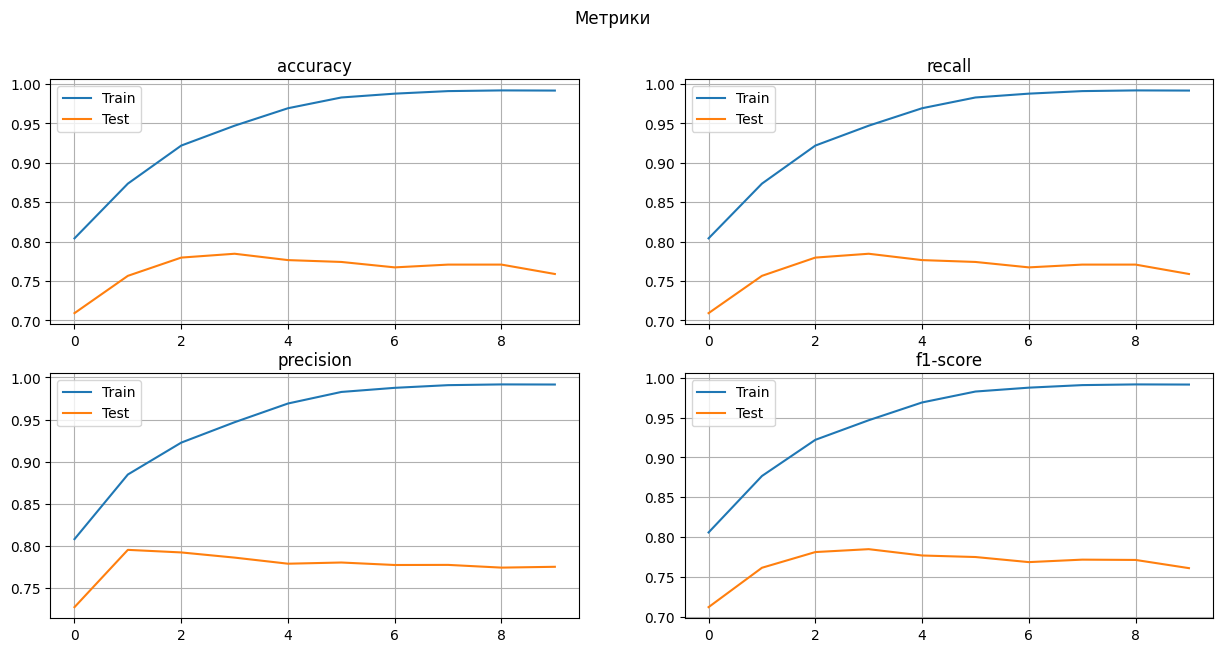

In [134]:
draw_metrics()

# Model 2

In [34]:
class GRU(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_size, output_size, padding_idx):
        super(GRU, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        self.embedding = Embedding(input_size, embedding_dim, padding_idx = padding_idx)
        self.gru = nn.GRU(embedding_dim, hidden_size, num_layers=1, batch_first=True) #  dropout=0.25
        self.fc = Linear(hidden_size, output_size)
        self.sig = nn.Sigmoid()

    def forward(self, text):
        embedded = self.embedding(text)
        # print(embedded.shape)
        output, hidden = self.gru(embedded)
        # print(output.shape)

        output = self.fc(output[:, -1, :])
        output = self.sig(output)
       
        return output

In [35]:
model = GRU(input_size=len(word_dict),
            embedding_dim=64,
            hidden_size=128,
            output_size=2,
            padding_idx = word_dict[padding]
)

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
weight = torch.Tensor(class_weights).to(device)
print('Weight', weight)
loss_fn = nn.BCELoss(weight=weight)

print(model)

Weight tensor([0.3215, 0.6785], device='cuda:0')
GRU(
  (embedding): Embedding(65874, 64, padding_idx=45947)
  (gru): GRU(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (sig): Sigmoid()
)


In [36]:
train_model(model, epochs = 10)

100%|██████████████████████████████████████| 4539/4539 [00:18<00:00, 239.22it/s]


Epoch: 0
Train
F1-мера: 84.12%
Precision: 84.12%
Recall: 84.12%
Accuracy: 84.12%
Loss: 771.76
Матрица ошибок:
       0      1
0  10986   3607
1   3600  27197
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75     14593
           1       0.88      0.88      0.88     30797

    accuracy                           0.84     45390
   macro avg       0.82      0.82      0.82     45390
weighted avg       0.84      0.84      0.84     45390

Test
F1-мера: 75.44%
Precision: 76.21%
Recall: 75.34%
Accuracy: 75.34%
Loss: 144.75
Матрица ошибок:
      0     1
0  2047   932
1   538  2443
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.79      0.69      0.74      2979
           1       0.72      0.82      0.77      2981

    accuracy                           0.75      5960
   macro av

100%|██████████████████████████████████████| 4539/4539 [00:18<00:00, 249.70it/s]


Epoch: 1
Train
F1-мера: 89.61%
Precision: 89.63%
Recall: 89.60%
Accuracy: 89.60%
Loss: 543.06
Матрица ошибок:
       0      1
0  12161   2432
1   2288  28509
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84     14593
           1       0.92      0.93      0.92     30797

    accuracy                           0.90     45390
   macro avg       0.88      0.88      0.88     45390
weighted avg       0.90      0.90      0.90     45390

Test
F1-мера: 77.19%
Precision: 77.92%
Recall: 77.10%
Accuracy: 77.10%
Loss: 141.03
Матрица ошибок:
      0     1
0  2106   873
1   492  2489
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.81      0.71      0.76      2979
           1       0.74      0.83      0.78      2981

    accuracy                           0.77      5960
   macro av

100%|██████████████████████████████████████| 4539/4539 [00:18<00:00, 251.88it/s]


...

Epoch: 7
Train
F1-мера: 99.14%
Precision: 99.14%
Recall: 99.14%
Accuracy: 99.14%
Loss: 57.33
Матрица ошибок:
       0      1
0  14379    214
1    175  30622
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     14593
           1       0.99      0.99      0.99     30797

    accuracy                           0.99     45390
   macro avg       0.99      0.99      0.99     45390
weighted avg       0.99      0.99      0.99     45390

Test
F1-мера: 77.47%
Precision: 77.73%
Recall: 77.43%
Accuracy: 77.43%
Loss: 269.74
Матрица ошибок:
      0     1
0  2191   788
1   557  2424
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77      2979
           1       0.75      0.81      0.78      2981

    accuracy                           0.77      5960
   macro avg

100%|██████████████████████████████████████| 4539/4539 [00:18<00:00, 248.23it/s]


Epoch: 8
Train
F1-мера: 99.30%
Precision: 99.30%
Recall: 99.30%
Accuracy: 99.30%
Loss: 45.91
Матрица ошибок:
       0      1
0  14437    156
1    163  30634
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     14593
           1       0.99      0.99      0.99     30797

    accuracy                           0.99     45390
   macro avg       0.99      0.99      0.99     45390
weighted avg       0.99      0.99      0.99     45390

Test
F1-мера: 77.32%
Precision: 77.71%
Recall: 77.27%
Accuracy: 77.27%
Loss: 294.88
Матрица ошибок:
      0     1
0  2161   818
1   537  2444
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.80      0.73      0.76      2979
           1       0.75      0.82      0.78      2981

    accuracy                           0.77      5960
   macro avg

100%|██████████████████████████████████████| 4539/4539 [00:17<00:00, 252.24it/s]


Epoch: 9
Train
F1-мера: 99.32%
Precision: 99.32%
Recall: 99.32%
Accuracy: 99.32%
Loss: 42.69
Матрица ошибок:
       0      1
0  14480    113
1    195  30602
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     14593
           1       1.00      0.99      0.99     30797

    accuracy                           0.99     45390
   macro avg       0.99      0.99      0.99     45390
weighted avg       0.99      0.99      0.99     45390

Test
F1-мера: 76.93%
Precision: 77.32%
Recall: 76.88%
Accuracy: 76.88%
Loss: 294.49
Матрица ошибок:
      0     1
0  2150   829
1   549  2432
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.80      0.72      0.76      2979
           1       0.75      0.82      0.78      2981

    accuracy                           0.77      5960
   macro avg

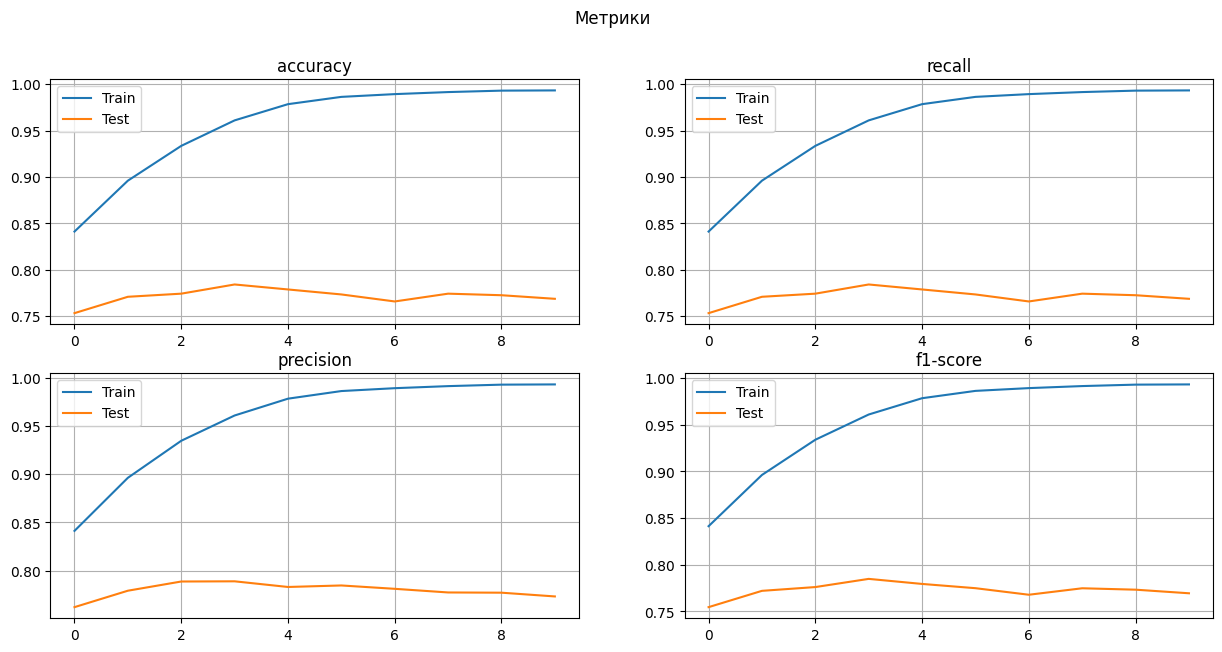

In [37]:
draw_metrics()

# Model 3

In [41]:
class GRU(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_size, output_size, padding_idx):
        super(GRU, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        self.embedding = Embedding(input_size, embedding_dim, padding_idx = padding_idx)
        self.gru = nn.GRU(embedding_dim, hidden_size, num_layers=1, batch_first=True) #  dropout=0.25
        self.gru2 = nn.GRU(hidden_size, hidden_size*2, num_layers=1, batch_first=True) #  dropout=0.25
        self.dropout = nn.Dropout(0.2)
        self.fc = Linear(hidden_size*2, output_size)
        self.sig = nn.Sigmoid()

    def forward(self, text):
        embedded = self.embedding(text)
        # print(embedded.shape)
        output, hidden = self.gru(embedded)
        output, hidden = self.gru2(output)
        # print(output.shape)
        output = self.dropout(output)
        output = self.fc(output[:, -1, :])
        output = self.sig(output)
       
        return output

In [58]:
model = GRU(input_size=len(word_dict),
            embedding_dim=64,
            hidden_size=128,
            output_size=2,
            padding_idx = word_dict[padding]
)

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
weight = torch.Tensor(class_weights).to(device)
print('Weight', weight)
loss_fn = nn.BCELoss(weight=weight)

print(model)

Weight tensor([0.3215, 0.6785], device='cuda:0')
GRU(
  (embedding): Embedding(65874, 64, padding_idx=45947)
  (gru): GRU(64, 128, batch_first=True)
  (gru2): GRU(128, 256, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
  (sig): Sigmoid()
)


In [59]:
train_model(model, epochs = 10)

100%|███████████████████████████████████████| 4539/4539 [00:48<00:00, 93.10it/s]


Epoch: 0
Train
F1-мера: 85.02%
Precision: 85.50%
Recall: 84.77%
Accuracy: 84.77%
Loss: 731.27
Матрица ошибок:
       0      1
0  10328   4265
1   2649  28148
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.80      0.71      0.75     14593
           1       0.87      0.91      0.89     30797

    accuracy                           0.85     45390
   macro avg       0.83      0.81      0.82     45390
weighted avg       0.85      0.85      0.85     45390

Test
F1-мера: 74.55%
Precision: 76.79%
Recall: 74.21%
Accuracy: 74.21%
Loss: 150.51
Матрица ошибок:
      0     1
0  1872  1107
1   430  2551
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.81      0.63      0.71      2979
           1       0.70      0.86      0.77      2981

    accuracy                           0.74      5960
   macro av

100%|███████████████████████████████████████| 4539/4539 [00:48<00:00, 93.12it/s]


Epoch: 1
Train
F1-мера: 90.00%
Precision: 90.12%
Recall: 89.92%
Accuracy: 89.92%
Loss: 537.79
Матрица ошибок:
       0      1
0  11927   2666
1   1908  28889
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     14593
           1       0.92      0.94      0.93     30797

    accuracy                           0.90     45390
   macro avg       0.89      0.88      0.88     45390
weighted avg       0.90      0.90      0.90     45390

Test
F1-мера: 78.25%
Precision: 79.46%
Recall: 78.10%
Accuracy: 78.10%
Loss: 136.36
Матрица ошибок:
      0     1
0  2081   898
1   407  2574
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.84      0.70      0.76      2979
           1       0.74      0.86      0.80      2981

    accuracy                           0.78      5960
   macro av

100%|███████████████████████████████████████| 4539/4539 [00:48<00:00, 93.01it/s]


...

Epoch: 7
Train
F1-мера: 99.11%
Precision: 99.12%
Recall: 99.11%
Accuracy: 99.11%
Loss: 57.97
Матрица ошибок:
       0      1
0  14375    218
1    184  30613
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     14593
           1       0.99      0.99      0.99     30797

    accuracy                           0.99     45390
   macro avg       0.99      0.99      0.99     45390
weighted avg       0.99      0.99      0.99     45390

Test
F1-мера: 77.12%
Precision: 77.65%
Recall: 77.05%
Accuracy: 77.05%
Loss: 284.26
Матрица ошибок:
      0     1
0  2132   847
1   521  2460
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.80      0.72      0.76      2979
           1       0.74      0.83      0.78      2981

    accuracy                           0.77      5960
   macro avg

100%|███████████████████████████████████████| 4539/4539 [00:49<00:00, 91.94it/s]


Epoch: 8
Train
F1-мера: 99.16%
Precision: 99.16%
Recall: 99.16%
Accuracy: 99.16%
Loss: 50.16
Матрица ошибок:
       0      1
0  14345    248
1    133  30664
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     14593
           1       0.99      1.00      0.99     30797

    accuracy                           0.99     45390
   macro avg       0.99      0.99      0.99     45390
weighted avg       0.99      0.99      0.99     45390

Test
F1-мера: 77.21%
Precision: 78.05%
Recall: 77.10%
Accuracy: 77.10%
Loss: 316.86
Матрица ошибок:
      0     1
0  2091   888
1   477  2504
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.81      0.70      0.75      2979
           1       0.74      0.84      0.79      2981

    accuracy                           0.77      5960
   macro avg

100%|███████████████████████████████████████| 4539/4539 [00:49<00:00, 91.85it/s]


Epoch: 9
Train
F1-мера: 99.21%
Precision: 99.21%
Recall: 99.21%
Accuracy: 99.21%
Loss: 46.85
Матрица ошибок:
       0      1
0  14381    212
1    148  30649
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     14593
           1       0.99      1.00      0.99     30797

    accuracy                           0.99     45390
   macro avg       0.99      0.99      0.99     45390
weighted avg       0.99      0.99      0.99     45390

Test
F1-мера: 76.57%
Precision: 76.89%
Recall: 76.53%
Accuracy: 76.53%
Loss: 339.14
Матрица ошибок:
      0     1
0  2153   826
1   573  2408
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.79      0.72      0.75      2979
           1       0.74      0.81      0.77      2981

    accuracy                           0.77      5960
   macro avg

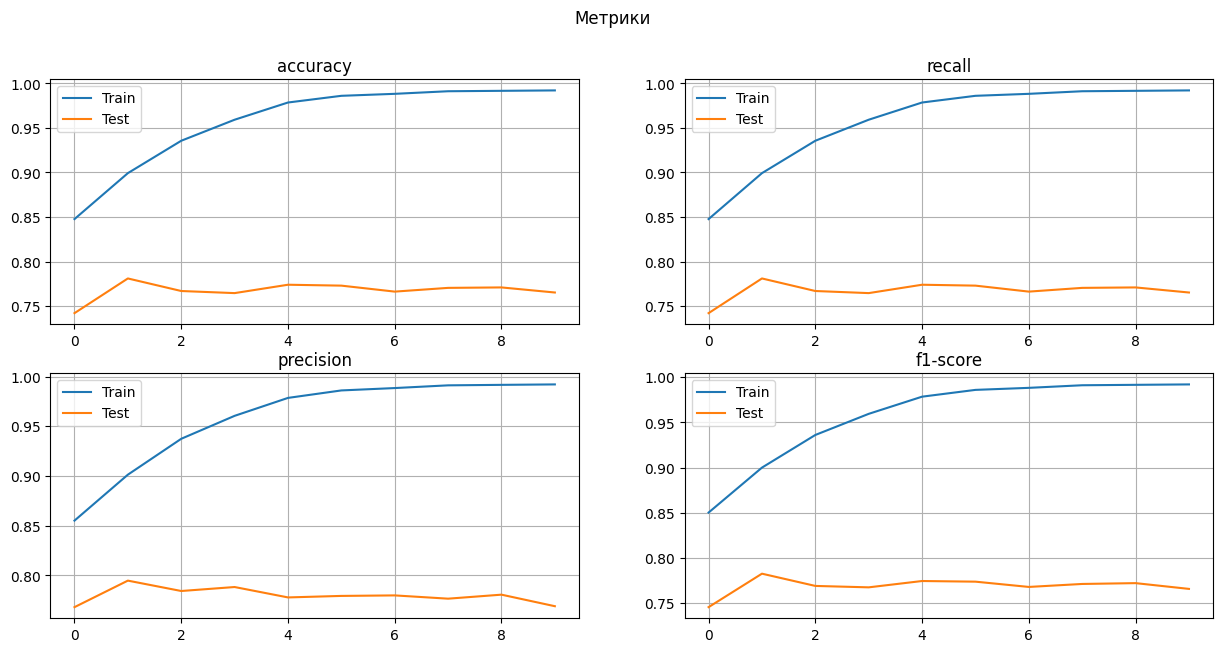

In [60]:
draw_metrics()

##  Word2vec

In [27]:
embedding_dim = 64

In [28]:
corp = del_stopwords(train.lemma.tolist())

In [29]:
corp.append(['__pad__'])
w2v_model = Word2Vec(corp, vector_size=embedding_dim, window=5, min_count=1, workers=4)

In [30]:
def preprocess_text(texts, word_dict, max_len, pad_index):
    result = []
    for i in texts:
        tmp = []
        i.append('__pad__') # for bigrams
        for j in range(max_len):
            if len(i)-1 > j and f'{i[j]}_{i[j+1]}' in word_dict:# for bigrams
                word = f'{i[j]}_{i[j+1]}'
                tmp.append(word_dict[word])
            elif len(i)-1 > j and i[j] in word_dict:
                word = i[j]
                tmp.append(word_dict[word])
            else:
                tmp.append(pad_index)
        result.append(tmp)
    return result

pad_idx = w2v_model.wv.get_index('__pad__')
tmp = np.array(preprocess_text(corp[:5], w2v_model.wv.key_to_index, 6, w2v_model.wv.get_index('__pad__')))
tmp.shape, tmp

((5, 6),
 array([[  851, 39523, 39523, 39523, 39523, 39523],
        [    0,    53,   227,   402,  1041,   114],
        [  799, 39523, 39523, 39523, 39523, 39523],
        [14360, 10285,  2484,     0,  5054, 39523],
        [18966,   217,   777,   624, 39523, 39523]]))

In [31]:
train_corp = del_stopwords(train.lemma.tolist())
test_corp = del_stopwords(test.lemma.tolist())

In [33]:
train_texts = preprocess_text(train_corp, w2v_model.wv.key_to_index, max_len, pad_idx)
test_texts = preprocess_text(test_corp, w2v_model.wv.key_to_index, max_len, pad_idx)

In [34]:
num = len(w2v_model.wv.index_to_key)
dim = w2v_model.vector_size
num, dim

(65892, 64)

In [35]:
def get_embedding(model, num, dim):
    emb_weights = np.zeros((num, dim))
    
    for key, i in enumerate(model.wv.key_to_index.keys()):
        emb_weights[key] = model.wv[i]
    emb_weights = torch.Tensor(emb_weights)
    print('Embedding len:', emb_weights.shape)
    return emb_weights

In [36]:
emb_weights = get_embedding(w2v_model, num, dim)

Embedding len: torch.Size([65892, 64])


In [46]:
batch_size = 200

train = TensorDataset(torch.IntTensor(train_texts), torch.FloatTensor(y_train.toarray()))
test = TensorDataset(torch.IntTensor(test_texts), torch.FloatTensor(y_test.toarray()))
    
train_loader = DataLoader(train,  batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=True)

In [44]:
len(train_texts)

45398

In [47]:
class GRU(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_size, output_size, padding_idx, weigths):
        super(GRU, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        self.embedding = Embedding(input_size, embedding_dim, padding_idx = padding_idx, _weight = weigths)
        self.gru = nn.GRU(embedding_dim, hidden_size, num_layers=2, batch_first=True) #  dropout=0.25
        self.fc = Linear(hidden_size, output_size)
        self.sig = nn.Sigmoid()

    def forward(self, text):
        embedded = self.embedding(text)
        # print(embedded.shape)
        output, hidden = self.gru(embedded)
        # print(output.shape)

        output = self.fc(output[:, -1, :])
        output = self.sig(output)
       
        return output

In [49]:
model = GRU(input_size=num,
            embedding_dim=64,
            hidden_size=128,
            output_size=2,
            padding_idx = word_dict[padding],
            weigths = emb_weights
)

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
weight = torch.Tensor(class_weights).to(device)
print('Weight', weight)
loss_fn = nn.BCELoss(weight=weight)

print(model)

Weight tensor([0.3215, 0.6785], device='cuda:0')
GRU(
  (embedding): Embedding(65892, 64, padding_idx=56775)
  (gru): GRU(64, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (sig): Sigmoid()
)


In [51]:
train_model(model, epochs = 10)

100%|█████████████████████████████████████████| 227/227 [00:10<00:00, 22.27it/s]


Epoch: 0
Train
F1-мера: 79.38%
Precision: 97.04%
Recall: 68.05%
Accuracy: 68.05%
Loss: 56.18
Матрица ошибок:
     0      1
0  467  14134
1  369  30428
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.56      0.03      0.06     14601
           1       0.68      0.99      0.81     30797

    accuracy                           0.68     45398
   macro avg       0.62      0.51      0.43     45398
weighted avg       0.64      0.68      0.57     45398

Test
F1-мера: 65.92%
Precision: 97.67%
Recall: 50.99%
Accuracy: 50.99%
Loss: 9.38
Матрица ошибок:
    0     1
0  79  2900
1  21  2960
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.79      0.03      0.05      2979
           1       0.51      0.99      0.67      2981

    accuracy                           0.51      5960
   macro avg       0.65   

100%|█████████████████████████████████████████| 227/227 [00:09<00:00, 23.34it/s]


Epoch: 1
Train
F1-мера: 79.51%
Precision: 80.14%
Recall: 79.99%
Accuracy: 79.99%
Loss: 43.51
Матрица ошибок:
       0      1
0  11872   2729
1   6357  24440
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.65      0.81      0.72     14601
           1       0.90      0.79      0.84     30797

    accuracy                           0.80     45398
   macro avg       0.78      0.80      0.78     45398
weighted avg       0.82      0.80      0.80     45398

Test
F1-мера: 74.61%
Precision: 75.04%
Recall: 74.55%
Accuracy: 74.55%
Loss: 7.44
Матрица ошибок:
      0     1
0  2369   610
1   907  2074
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.72      0.80      0.76      2979
           1       0.77      0.70      0.73      2981

    accuracy                           0.75      5960
   macro avg  

100%|█████████████████████████████████████████| 227/227 [00:09<00:00, 23.14it/s]


...

Epoch: 7
Train
F1-мера: 97.91%
Precision: 97.91%
Recall: 97.91%
Accuracy: 97.91%
Loss: 6.32
Матрица ошибок:
       0      1
0  14130    471
1    478  30319
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     14601
           1       0.98      0.98      0.98     30797

    accuracy                           0.98     45398
   macro avg       0.98      0.98      0.98     45398
weighted avg       0.98      0.98      0.98     45398

Test
F1-мера: 78.15%
Precision: 78.42%
Recall: 78.12%
Accuracy: 78.12%
Loss: 11.01
Матрица ошибок:
      0     1
0  2211   768
1   536  2445
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77      2979
           1       0.76      0.82      0.79      2981

    accuracy                           0.78      5960
   macro avg  

100%|█████████████████████████████████████████| 227/227 [00:09<00:00, 23.18it/s]


Epoch: 8
Train
F1-мера: 98.43%
Precision: 98.43%
Recall: 98.42%
Accuracy: 98.42%
Loss: 5.02
Матрица ошибок:
       0      1
0  14157    444
1    272  30525
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     14601
           1       0.99      0.99      0.99     30797

    accuracy                           0.98     45398
   macro avg       0.98      0.98      0.98     45398
weighted avg       0.98      0.98      0.98     45398

Test
F1-мера: 77.75%
Precision: 78.28%
Recall: 77.68%
Accuracy: 77.68%
Loss: 12.96
Матрица ошибок:
      0     1
0  2152   827
1   503  2478
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.81      0.72      0.76      2979
           1       0.75      0.83      0.79      2981

    accuracy                           0.78      5960
   macro avg  

100%|█████████████████████████████████████████| 227/227 [00:09<00:00, 23.22it/s]


Epoch: 9
Train
F1-мера: 98.64%
Precision: 98.64%
Recall: 98.64%
Accuracy: 98.64%
Loss: 4.24
Матрица ошибок:
       0      1
0  14250    351
1    268  30529
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     14601
           1       0.99      0.99      0.99     30797

    accuracy                           0.99     45398
   macro avg       0.99      0.98      0.98     45398
weighted avg       0.99      0.99      0.99     45398

Test
F1-мера: 77.18%
Precision: 77.97%
Recall: 77.08%
Accuracy: 77.08%
Loss: 14.24
Матрица ошибок:
      0     1
0  2097   882
1   484  2497
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.81      0.70      0.75      2979
           1       0.74      0.84      0.79      2981

    accuracy                           0.77      5960
   macro avg  

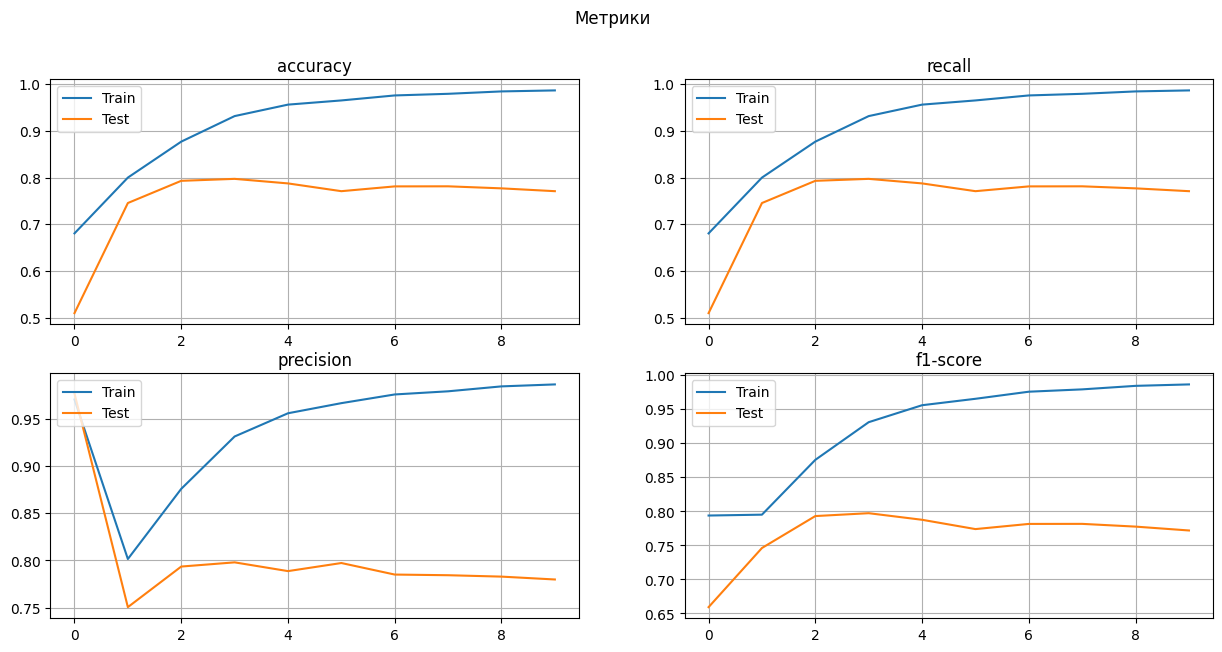

In [52]:
draw_metrics()

In [53]:
class SelfAttention(nn.Module):
    def __init__(self, input_dim):
        super(SelfAttention, self).__init__()
        self.input_dim = input_dim
        self.query = nn.Linear(input_dim, input_dim)
        self.key = nn.Linear(input_dim, input_dim)
        self.value = nn.Linear(input_dim, input_dim)
        self.softmax = nn.Softmax(dim=2)
        
    def forward(self, x):
        queries = self.query(x)
        keys = self.key(x)
        values = self.value(x)
        scores = torch.bmm(queries, keys.transpose(1, 2)) / (self.input_dim ** 0.5)
        attention = self.softmax(scores)
        weighted = torch.bmm(attention, values)
        return weighted

In [54]:
class GRU(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_size, output_size, padding_idx, weigths):
        super(GRU, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        self.embedding = Embedding(input_size, embedding_dim, padding_idx = padding_idx, _weight = weigths)
        self.gru = nn.GRU(embedding_dim, hidden_size, num_layers=2, batch_first=True) #  dropout=0.25
        self.attention = SelfAttention(hidden_size)
        self.fc = Linear(hidden_size, output_size)
        self.sig = nn.Sigmoid()

    def forward(self, text):
        embedded = self.embedding(text)
        # print(embedded.shape)
        output, hidden = self.gru(embedded)
        # print(output.shape)
        output = self.attention(output)
        output = self.fc(output[:, -1, :])
        output = self.sig(output)
       
        return output

In [55]:
model = GRU(input_size=num,
            embedding_dim=64,
            hidden_size=128,
            output_size=2,
            padding_idx = word_dict[padding],
            weigths = emb_weights
)

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
weight = torch.Tensor(class_weights).to(device)
print('Weight', weight)
loss_fn = nn.BCELoss(weight=weight)

print(model)

Weight tensor([0.3215, 0.6785], device='cuda:0')
GRU(
  (embedding): Embedding(65892, 64, padding_idx=56775)
  (gru): GRU(64, 128, num_layers=2, batch_first=True)
  (attention): SelfAttention(
    (query): Linear(in_features=128, out_features=128, bias=True)
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
    (softmax): Softmax(dim=2)
  )
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (sig): Sigmoid()
)


In [56]:
train_model(model, epochs = 10)

100%|█████████████████████████████████████████| 227/227 [00:14<00:00, 15.92it/s]


Epoch: 0
Train
F1-мера: 82.39%
Precision: 85.14%
Recall: 81.31%
Accuracy: 81.31%
Loss: 40.98
Матрица ошибок:
      0      1
0  8083   6518
1  1967  28830
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.80      0.55      0.66     14601
           1       0.82      0.94      0.87     30797

    accuracy                           0.81     45398
   macro avg       0.81      0.74      0.76     45398
weighted avg       0.81      0.81      0.80     45398

Test
F1-мера: 71.62%
Precision: 78.12%
Recall: 70.44%
Accuracy: 70.44%
Loss: 7.81
Матрица ошибок:
      0     1
0  1514  1465
1   297  2684
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.84      0.51      0.63      2979
           1       0.65      0.90      0.75      2981

    accuracy                           0.70      5960
   macro avg     

100%|█████████████████████████████████████████| 227/227 [00:14<00:00, 15.86it/s]


Epoch: 1
Train
F1-мера: 88.09%
Precision: 88.06%
Recall: 88.13%
Accuracy: 88.13%
Loss: 30.17
Матрица ошибок:
       0      1
0  12092   2509
1   2881  27916
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82     14601
           1       0.92      0.91      0.91     30797

    accuracy                           0.88     45398
   macro avg       0.86      0.87      0.86     45398
weighted avg       0.88      0.88      0.88     45398

Test
F1-мера: 79.26%
Precision: 79.49%
Recall: 79.23%
Accuracy: 79.23%
Loss: 6.48
Матрица ошибок:
      0     1
0  2252   727
1   511  2470
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.82      0.76      0.78      2979
           1       0.77      0.83      0.80      2981

    accuracy                           0.79      5960
   macro avg  

100%|█████████████████████████████████████████| 227/227 [00:14<00:00, 15.80it/s]


...

Epoch: 7
Train
F1-мера: 98.13%
Precision: 98.15%
Recall: 98.12%
Accuracy: 98.12%
Loss: 5.51
Матрица ошибок:
       0      1
0  13977    624
1    230  30567
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     14601
           1       0.98      0.99      0.99     30797

    accuracy                           0.98     45398
   macro avg       0.98      0.97      0.98     45398
weighted avg       0.98      0.98      0.98     45398

Test
F1-мера: 75.79%
Precision: 77.83%
Recall: 75.50%
Accuracy: 75.50%
Loss: 17.60
Матрица ошибок:
      0     1
0  1928  1051
1   409  2572
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.82      0.65      0.73      2979
           1       0.71      0.86      0.78      2981

    accuracy                           0.76      5960
   macro avg  

100%|█████████████████████████████████████████| 227/227 [00:14<00:00, 15.75it/s]


Epoch: 8
Train
F1-мера: 98.53%
Precision: 98.54%
Recall: 98.53%
Accuracy: 98.53%
Loss: 4.42
Матрица ошибок:
       0      1
0  14236    365
1    301  30496
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     14601
           1       0.99      0.99      0.99     30797

    accuracy                           0.99     45398
   macro avg       0.98      0.98      0.98     45398
weighted avg       0.99      0.99      0.99     45398

Test
F1-мера: 76.94%
Precision: 77.69%
Recall: 76.85%
Accuracy: 76.85%
Loss: 15.75
Матрица ошибок:
      0     1
0  2096   883
1   497  2484
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.81      0.70      0.75      2979
           1       0.74      0.83      0.78      2981

    accuracy                           0.77      5960
   macro avg  

100%|█████████████████████████████████████████| 227/227 [00:14<00:00, 15.57it/s]


Epoch: 9
Train
F1-мера: 98.76%
Precision: 98.76%
Recall: 98.76%
Accuracy: 98.76%
Loss: 3.67
Матрица ошибок:
       0      1
0  14263    338
1    226  30571
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     14601
           1       0.99      0.99      0.99     30797

    accuracy                           0.99     45398
   macro avg       0.99      0.98      0.99     45398
weighted avg       0.99      0.99      0.99     45398

Test
F1-мера: 76.47%
Precision: 77.66%
Recall: 76.31%
Accuracy: 76.31%
Loss: 20.90
Матрица ошибок:
      0     1
0  2028   951
1   461  2520
------------------------------------------------
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.81      0.68      0.74      2979
           1       0.73      0.85      0.78      2981

    accuracy                           0.76      5960
   macro avg  

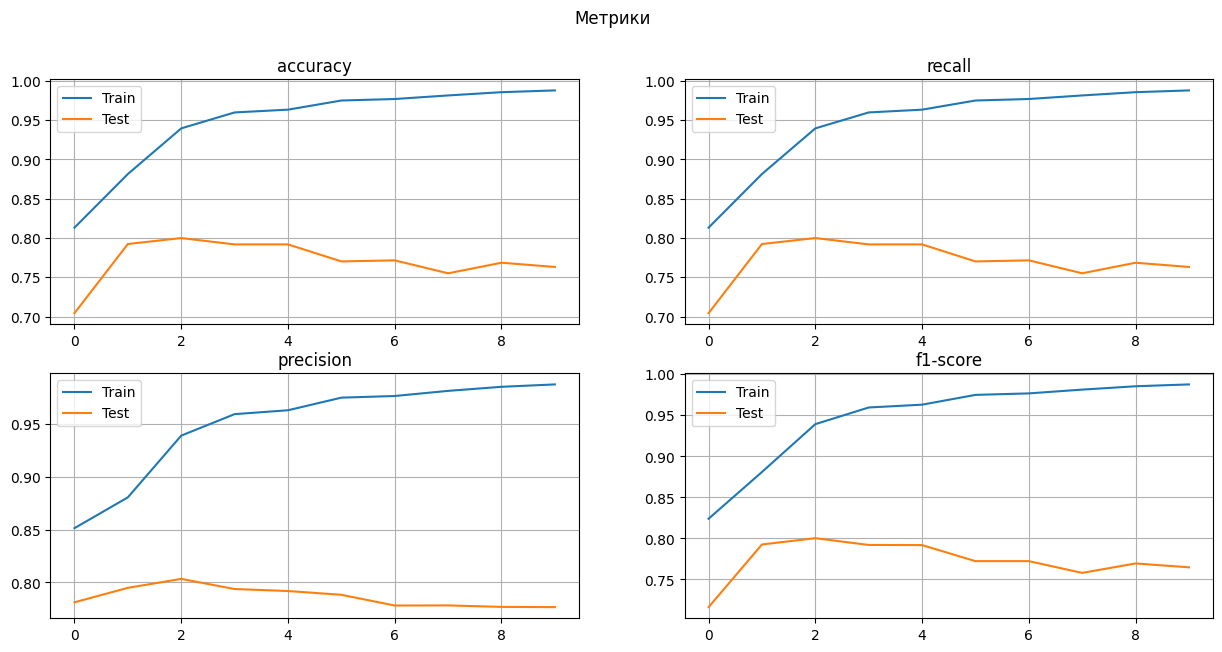

In [57]:
draw_metrics()

# Find wrong exampes

In [48]:
model(torch.IntTensor(X_test[:10]).to(device))

tensor([[3.9816e-02, 9.6013e-01],
        [1.0901e-02, 9.8911e-01],
        [8.6759e-05, 9.9991e-01],
        [1.5445e-02, 9.8455e-01],
        [6.6742e-06, 9.9999e-01],
        [1.7653e-04, 9.9982e-01],
        [8.5964e-01, 1.4055e-01],
        [3.5972e-04, 9.9964e-01],
        [3.0777e-02, 9.6919e-01],
        [5.6332e-01, 4.3612e-01]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [89]:
num2word = {value: key for key, value in word_dict.items()}

In [93]:
def token2text(tokens, pad):
    text = []
    for i in tokens:
        # print(i)
        if int(i) in num2word and int(i) != pad:
            text.append(num2word[i])
    return ' '.join(text)

In [116]:
wrong_ex = []
idx = 0
for i in range(0, len(X_test)-10, 10):
    pred = model(torch.IntTensor(X_test[i: i+10]).to(device))
    pred = [j.argmax().cpu() for j in pred]
    y = [j.argmax() for j in y_test[i: i+10]]
    texts = [token2text(i, pad = 0) for i in X_test[i: i+10]] # word_dict[padding]
    # print(texts)

    c = np.array(pred) != np.array(y)
    num = np.arange(0, 10)
    # print(num[c], c)

    for j in num[c]:
        wrong_ex.append((y[j], pred[j], texts[j]))

    if idx > 1000:
        break
    idx+=1

# pred, y[:10], 
len(wrong_ex), wrong_ex

(1407,
 [(1,
   tensor(0),
   'спосибо дорога са истерика псих каприз понимать никто родной изменить жызнь сторона добавить яркий краска изменить понятие жызнь улыбаться извенеть отношение бороться благодаря день год вместе простить очень любить'),
  (1, tensor(0), 'аист'),
  (1, tensor(0), 'официальный бумажка _'),
  (1, tensor(0), 'вернуться родина'),
  (1, tensor(0), 'ай'),
  (1,
   tensor(0),
   'защитить диплом затем день бывать рай вернуться скоро снова пропасть неделька занять обучение активность просмотр любить'),
  (1,
   tensor(0),
   'смех сквозь слеза слеза сквозь смех палата послеоперационный релакс фото зеркало т е окно'),
  (1,
   tensor(0),
   'заслужить бавария победа вернуть былой слава спасибо поздравлять бавария'),
  (1, tensor(0), 'дрессировщик год'),
  (1, tensor(0), 'ласточка слушать исключительно'),
  (1, tensor(0), 'никто блин не лишь ходить голый рядом'),
  (1, tensor(0), 'последний получиться уф'),
  (1, tensor(0), 'слушать читать стать бабушка внучка'),
  (1

In [79]:
# test.loc[10]